# Replication: Sales Predictions for Video Games using Predictive Analytics of Market Data

**Paper:** Gray, D., Shalan, A. M., & Kadlec, C. (2024). *Sales Predictions for Video Games using Predictive Analytics of Market Data.*
2024 IEEE 16th International Conference on Computational Intelligence and Communication Networks (CICN).
DOI: [10.1109/CICN63059.2024.10847429](https://doi.org/10.1109/CICN63059.2024.10847429)

The original paper built its models in **Orange Data Mining**, a no-code visual workflow tool.
This notebook reproduces the same methodology (feature set, preprocessing, models, and evaluation
metrics) as plain, runnable Python using `pandas` / `scikit-learn`, so the approach can be
demonstrated and understood as code.

**Dataset:** Kaggle ["Video Game Sales and Ratings"](https://www.kaggle.com/datasets/thedevastator/video-game-sales-and-rating)


## Imports

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

RANDOM_STATE = 42
CSV_PATH = "video_game_sales_and_ratings.csv"


## Section III-A (Data Collection)

Load the raw dataset.

In [34]:
df = pd.read_csv(CSV_PATH)
df.head()

,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating
0,Wii Sports,Wii,2006.0,Sports,Nintendo,41.36,28.96,3.77,8.45,82.53,76.0,51.0,8,322.0,Nintendo,E
1,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,NaN,NaN,NaN,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.68,12.76,3.79,3.29,35.52,82.0,73.0,8.3,709.0,Nintendo,E
3,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.61,10.93,3.28,2.95,32.77,80.0,73.0,8,192.0,Nintendo,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,NaN,NaN,NaN,NaN,NaN,NaN


In [35]:
# The paper's feature list uses "index" as a feature, i.e. the row number of
# the dataset after loading. We reproduce that literally: it is simply the
# positional index of each row, carrying no real predictive information.
df = df.reset_index(drop=False)  # creates an "index" column: 0, 1, 2, ...

FEATURES = [
    "index",
    "Year_of_Release",
    "NA_Sales",
    "EU_Sales",
    "JP_Sales",
    "Other_Sales",
    "Critic_Score",
    "Critic_Count",
    "User_Count",
]
TARGET = "Global_Sales"
FEATURES

['index',
 'Year_of_Release',
 'NA_Sales',
 'EU_Sales',
 'JP_Sales',
 'Other_Sales',
 'Critic_Score',
 'Critic_Count',
 'User_Count']

## Section III-B (Data Preprocessing)

The paper describes a cleaning step to handle missing critic/user data before modeling.
We drop any row with a missing value in a feature or the target column, matching that description.

In [36]:
model_df = df[FEATURES + [TARGET]].dropna().reset_index(drop=True)

print(f"Rows before cleaning: {len(df)}")
print(f"Rows after dropping missing values in features/target: {len(model_df)}")
model_df.describe()

Rows before cleaning: 16719
Rows after dropping missing values in features/target: 6894


,index,Year_of_Release,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Critic_Score,Critic_Count,User_Count,Global_Sales
count,6894.000000,6894.000000,6894.000000,6894.000000,6894.000000,6894.00000,6894.000000,6894.000000,6894.000000,6894.000000
mean,6674.063969,2007.482303,0.390920,0.234517,0.063867,0.08200,70.258486,28.842472,174.392370,0.771487
std,4539.397588,4.236401,0.963231,0.684214,0.286461,0.26862,13.861082,19.194572,584.872155,1.954780
min,0.000000,1985.000000,0.000000,0.000000,0.000000,0.00000,13.000000,3.000000,4.000000,0.010000
25%,2735.250000,2004.000000,0.060000,0.020000,0.000000,0.01000,62.000000,14.000000,11.000000,0.110000
50%,6028.500000,2007.000000,0.150000,0.060000,0.000000,0.02000,72.000000,24.000000,27.000000,0.290000
75%,10167.250000,2011.000000,0.390000,0.210000,0.010000,0.07000,80.000000,39.000000,89.000000,0.750000
max,16709.000000,2016.000000,41.360000,28.960000,6.500000,10.57000,98.000000,113.000000,10665.000000,82.530000



`Global_Sales` is arithmetically defined as:

```
Global_Sales = NA_Sales + EU_Sales + JP_Sales + Other_Sales
```

in this dataset. Since all four regional sales columns are included as input features, a Linear
Regression model can recover `Global_Sales` almost exactly (coefficients ≈ 1.0 on each regional
feature, ≈ 0 on the rest) simply by re-deriving this near-identity sum. A very high R² here is
therefore **expected from this arithmetic relationship in the data**, and should **not** be
interpreted as evidence that the model is learning deeper market drivers of video game sales.

## Section III-C (Model Building)

Held-out train/test split, then fit both models.

In [37]:
X = model_df[FEATURES]
y = model_df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)
y_pred_lin = lin_reg.predict(X_test)

tree_reg = DecisionTreeRegressor(random_state=RANDOM_STATE)
tree_reg.fit(X_train, y_train)
y_pred_tree = tree_reg.predict(X_test)

print("Models fit.")

Models fit.


In [38]:
def compute_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    # MAPE: exclude rows where y_true == 0 to avoid division by zero.
    nonzero = y_true != 0
    mape = np.mean(np.abs((y_true[nonzero] - y_pred[nonzero]) / y_true[nonzero])) * 100
    r2 = r2_score(y_true, y_pred)
    return {"MSE": mse, "RMSE": rmse, "MAE": mae, "MAPE": mape, "R2": r2}

metrics_lin = compute_metrics(y_test, y_pred_lin)
metrics_tree = compute_metrics(y_test, y_pred_tree)
metrics_lin, metrics_tree

({'MSE': 3.368259059140982e-05,
  'RMSE': np.float64(0.005803670441316411),
  'MAE': 0.003680533515073838,
  'MAPE': np.float64(3.096661805350931),
  'R2': 0.999987604652618},
 {'MSE': 0.0021893401015228462,
  'RMSE': np.float64(0.04679038471227658),
  'MAE': 0.005503988397389524,
  'MAPE': np.float64(0.10935424718404624),
  'R2': 0.9991943128298919})

## Section IV, Table II — Model Performance Comparison

MSE, RMSE, MAE, MAPE, R² on the held-out test split.

In [39]:
results_df = pd.DataFrame(
    [metrics_lin, metrics_tree],
    index=["Linear Regression", "Decision Tree"],
)[["MSE", "RMSE", "MAE", "MAPE", "R2"]]
results_df.columns = ["MSE", "RMSE", "MAE", "MAPE (%)", "R^2"]
results_df.round(4)

,MSE,RMSE,MAE,MAPE (%),R^2
Linear Regression,0.0000,0.0058,0.0037,3.0967,1.0000
Decision Tree,0.0022,0.0468,0.0055,0.1094,0.9992


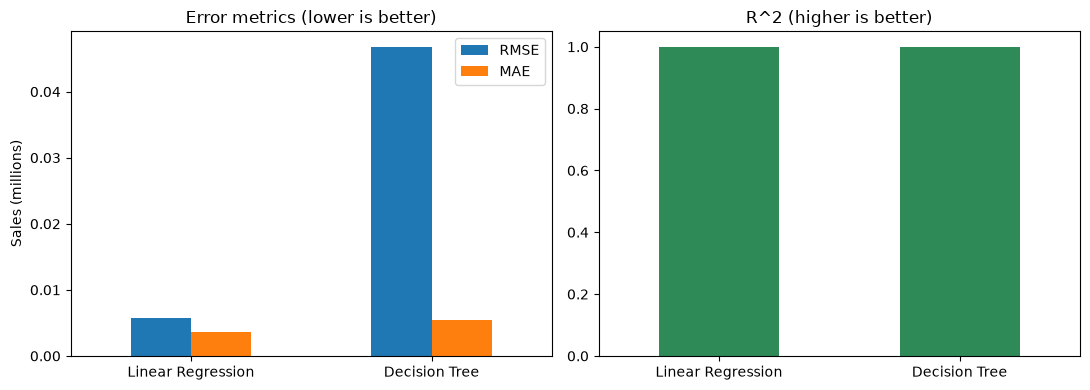

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

results_df[["RMSE", "MAE"]].plot(kind="bar", ax=axes[0])
axes[0].set_title("Error metrics (lower is better)")
axes[0].set_ylabel("Sales (millions)")
axes[0].tick_params(axis='x', rotation=0)

results_df["R^2"].plot(kind="bar", ax=axes[1], color="seagreen")
axes[1].set_title("R^2 (higher is better)")
axes[1].set_ylim(0, 1.05)
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

## Section IV, Fig. 2 — Bar Plot of Linear Regression Predictions

The paper's Fig. 2 (Orange Data Mining's Bar Plot widget) shows the Linear Regression model's
predicted sales values sorted in descending order, with each bar representing one video game
instance from the test set. Predictions decrease steadily from left to right; the paper notes
that this reflects higher predicted demand among the earlier-released games in the dataset.

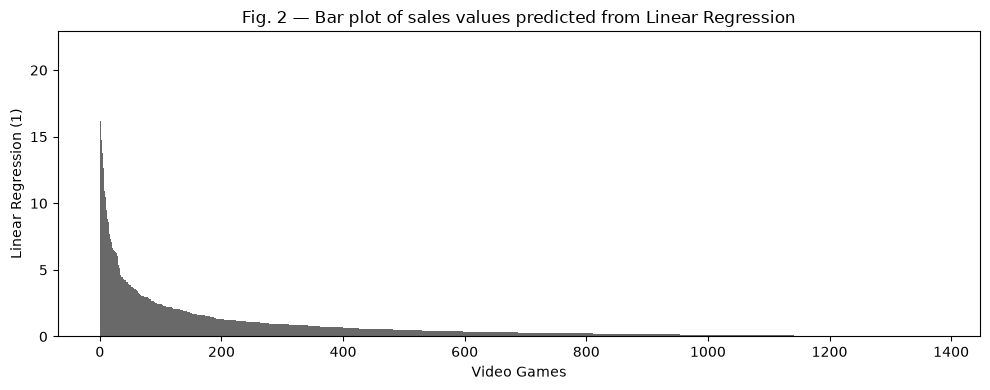

In [41]:
# Sort predictions descending to reproduce the shape of the paper's Fig. 2
# (Orange's Bar Plot widget orders instances by predicted value, not by index).
sorted_preds = np.sort(y_pred_lin)[::-1]

plt.figure(figsize=(10, 4))
plt.bar(range(len(sorted_preds)), sorted_preds, width=1.0, color="dimgray")
plt.xlabel("Video Games")
plt.ylabel("Linear Regression (1)")
plt.title("Fig. 2 — Bar plot of sales values predicted from Linear Regression")
plt.tight_layout()
plt.show()

## Section IV, Table III — Linear Regression Coefficients

Coefficient for each feature, matching the paper's Table III layout.

In [42]:
coef_df = pd.DataFrame({
    "Feature": ["(Intercept)"] + FEATURES,
    "Coefficient": [lin_reg.intercept_] + list(lin_reg.coef_),
})
coef_df

,Feature,Coefficient
0,(Intercept),-1.034486e-02
1,index,1.388634e-07
2,Year_of_Release,4.389973e-06
3,NA_Sales,1.000114e+00
4,EU_Sales,9.998108e-01
5,JP_Sales,9.995340e-01
6,Other_Sales,1.000229e+00
7,Critic_Score,9.021229e-06
8,Critic_Count,7.216551e-06
9,User_Count,-9.469084e-08


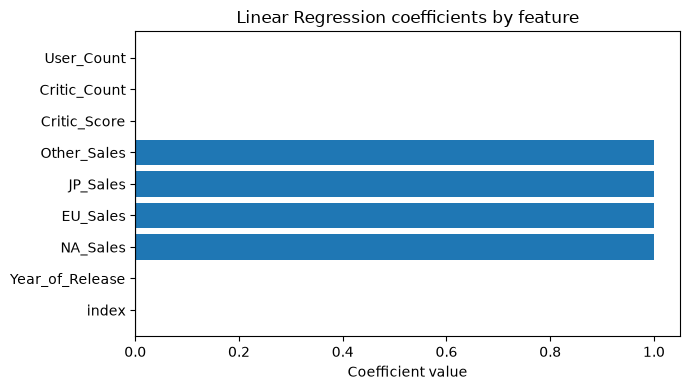

: 

In [ ]:
plt.figure(figsize=(7, 4))
plt.barh(coef_df["Feature"][1:], coef_df["Coefficient"][1:])
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Linear Regression coefficients by feature")
plt.xlabel("Coefficient value")
plt.tight_layout()
plt.show()